# Analysis of Sector STF Prices (2000): Financial Networks

In [14]:
'''Construction of dyanamic financial networks from etf price data, and analysis of their properties.'''

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns

import networkx as nx
from scipy.sparse.csgraph import minimum_spanning_tree

In [15]:
# Function to construct the minimum spanning tree graph from the distance matrix
def mst_graph(D: np.ndarray, stock_names: list[str]):
    mst_sparse = minimum_spanning_tree(D)
    mst_coo = mst_sparse.tocoo()

    G = nx.Graph()
    G.add_nodes_from(stock_names)

    for u, v, w in zip(mst_coo.row, mst_coo.col, mst_coo.data):
        G.add_edge(stock_names[u], stock_names[v], weight=float(w), edge_type="mst")

    return G

# Function to construct the threshold graph from the correlation matrix
def threshold_graph(C: np.ndarray, stock_names: list[str], corr_threshold: float):
    G = nx.Graph()
    G.add_nodes_from(stock_names)

    n = C.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if C[i, j] >= corr_threshold:
                G.add_edge(stock_names[i], stock_names[j], weight=C[i, j], edge_type="threshold")
    return G

# Function to construct the combined graph with both MST and threshold edges
def mst_threshold_graph(C: np.ndarray, D: np.ndarray, stock_names: list[str], corr_threshold: float):
    G = mst_graph(D, stock_names)
    
    n = C.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if C[i, j] >= corr_threshold and not G.has_edge(stock_names[i], stock_names[j]):
                G.add_edge(stock_names[i], stock_names[j], weight=C[i, j], edge_type="threshold")
    return G

### Exploratory Data Analysis

In [16]:
df_price = pd.read_csv("data/sector_etf_prices_cleaned.csv")
df_price["Date"] = pd.to_datetime(df_price["Date"], format="%Y-%m-%d")
df_price.head()

,Date,XLF,XLE,XLB,XLI,XLK,XLP,XLU,XLV,XLY
0,2000-01-03,11.147915,6.699405,7.260398,18.125662,20.652031,12.207148,5.551600,20.524773,11.173433
1,2000-01-04,10.660573,6.573296,7.190508,17.624897,19.604294,11.863403,5.384135,20.059027,10.837303
2,2000-01-05,10.576814,6.746696,7.487562,17.546352,19.313265,12.073002,5.520003,19.879080,10.704010
3,2000-01-06,11.041308,7.006788,7.679774,17.782003,18.672972,12.299375,5.510522,19.942579,10.825708
4,2000-01-07,11.224063,7.081666,7.675409,18.459503,18.998938,13.079090,5.557920,20.186052,11.335702


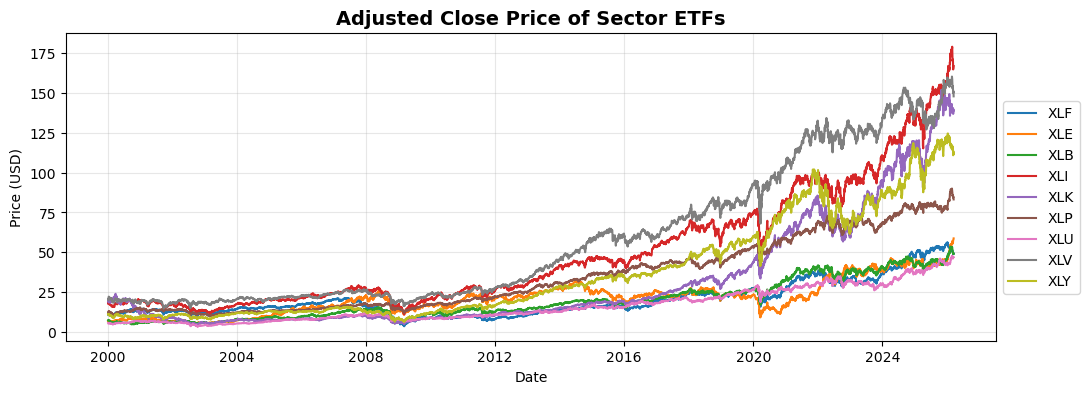

In [17]:
plt.figure(figsize=(12, 4))

for col in df_price.columns[1:]:
    plt.plot(df_price["Date"], df_price[col], label=col)

plt.title("Adjusted Close Price of Sector ETFs", fontsize=14, fontweight="bold")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.legend(loc="upper left", bbox_to_anchor=(1, 0.8))
plt.grid(True, alpha=0.3)
plt.savefig("images/fig1_prices_sectors2000.png", bbox_inches="tight")
plt.show()

In [18]:
df_logreturns = pd.DataFrame()
df_logreturns["Date"] = df_price["Date"]

for col in df_price.columns[1:]:
    df_logreturns[col] = np.log(df_price[col]) - np.log(df_price[col].shift(1))

df_logreturns = df_logreturns.dropna()
df_logreturns.head()

,Date,XLF,XLE,XLB,XLI,XLK,XLP,XLU,XLV,XLY
1,2000-01-04,-0.044700,-0.019003,-0.009673,-0.028016,-0.052065,-0.028563,-0.030630,-0.022953,-0.030545
2,2000-01-05,-0.007888,0.026037,0.040481,-0.004466,-0.014956,0.017513,0.024922,-0.009011,-0.012376
3,2000-01-06,0.042979,0.037827,0.025347,0.013341,-0.033715,0.018577,-0.001719,0.003189,0.011305
4,2000-01-07,0.016416,0.010630,-0.000568,0.037392,0.017306,0.061466,0.008565,0.012135,0.046033
5,2000-01-10,-0.017797,-0.008383,-0.003421,0.000000,0.037287,-0.022692,0.003405,0.097358,-0.005126


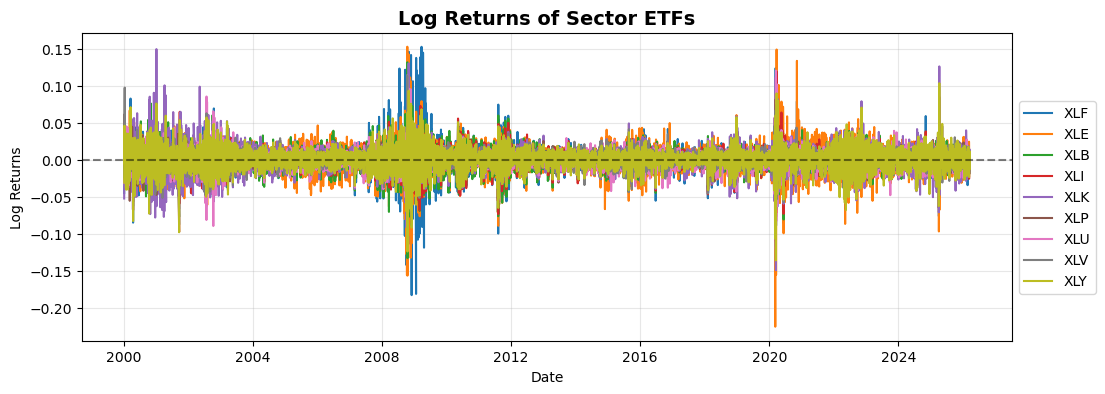

In [19]:
plt.figure(figsize=(12, 4))

for col in df_logreturns.columns[1:]:
    plt.plot(df_logreturns["Date"], df_logreturns[col], label=col)

plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.title("Log Returns of Sector ETFs", fontsize=14, fontweight="bold")
plt.ylabel("Log Returns")
plt.xlabel("Date")
plt.legend(loc="upper left", bbox_to_anchor=(1, 0.8))
plt.grid(True, alpha=0.3)
plt.savefig("images/fig2_logreturns_sectors2000.png", bbox_inches="tight")
plt.show()

In [20]:
df_logreturns.iloc[:, 1:].describe()
for col in df_logreturns.columns[1:]:
    print(f"{col} Skewness: {df_logreturns[col].skew():.4f}")
    print(f"{col} Kurtosis: {df_logreturns[col].kurtosis():.4f}\n")

XLF Skewness: -0.1574
XLF Kurtosis: 15.2412

XLE Skewness: -0.6519
XLE Kurtosis: 12.2894

XLB Skewness: -0.2144
XLB Kurtosis: 6.7425

XLI Skewness: -0.3412
XLI Kurtosis: 8.0678

XLK Skewness: 0.0891
XLK Kurtosis: 7.3006

XLP Skewness: -0.2643
XLP Kurtosis: 8.6537

XLU Skewness: -0.0568
XLU Kurtosis: 11.6017

XLV Skewness: -0.2329
XLV Kurtosis: 9.1929

XLY Skewness: -0.3628
XLY Kurtosis: 6.7726



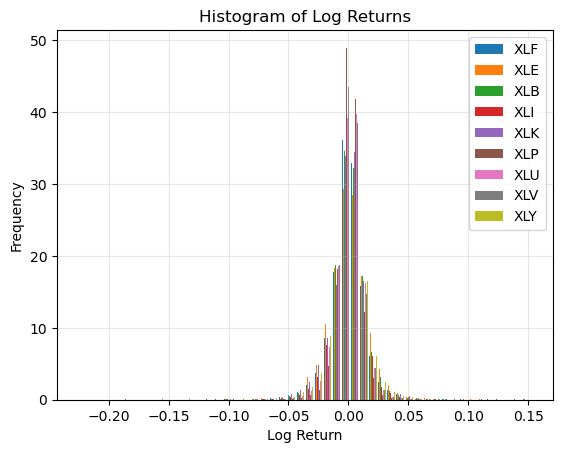

In [21]:
plt.hist(df_logreturns.iloc[:, 1:], bins=50, density=True, label=df_logreturns.columns[1:])
plt.title("Histogram of Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

### Global Relationship (2000 - 2026)

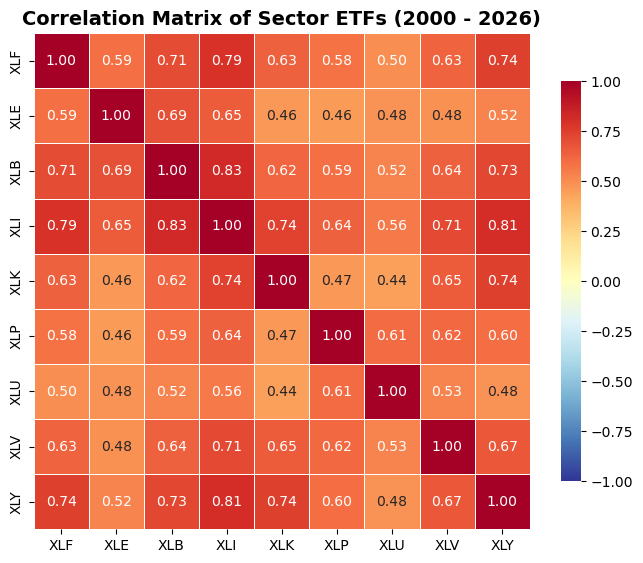

In [22]:
correlation_matrix = df_logreturns.iloc[:, 1:].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,)
plt.title("Correlation Matrix of Sector ETFs (2000 - 2026)", fontsize=14, fontweight="bold")
plt.savefig("images/fig3_corr_heatmap_sectors2000.png", dpi=200, bbox_inches="tight")
plt.show()

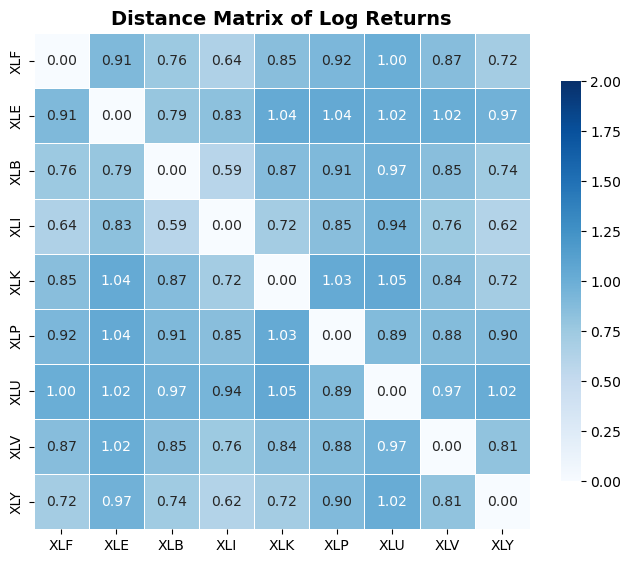

In [23]:
distance_matrix = np.sqrt(2 * (1 - correlation_matrix))

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(distance_matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=2, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,)
plt.title("Distance Matrix of Log Returns", fontsize=14, fontweight="bold")
plt.show()

C:\Users\Abbin\AppData\Local\Temp\ipykernel_25032\2737023257.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", n)


<Figure size 800x650 with 0 Axes>

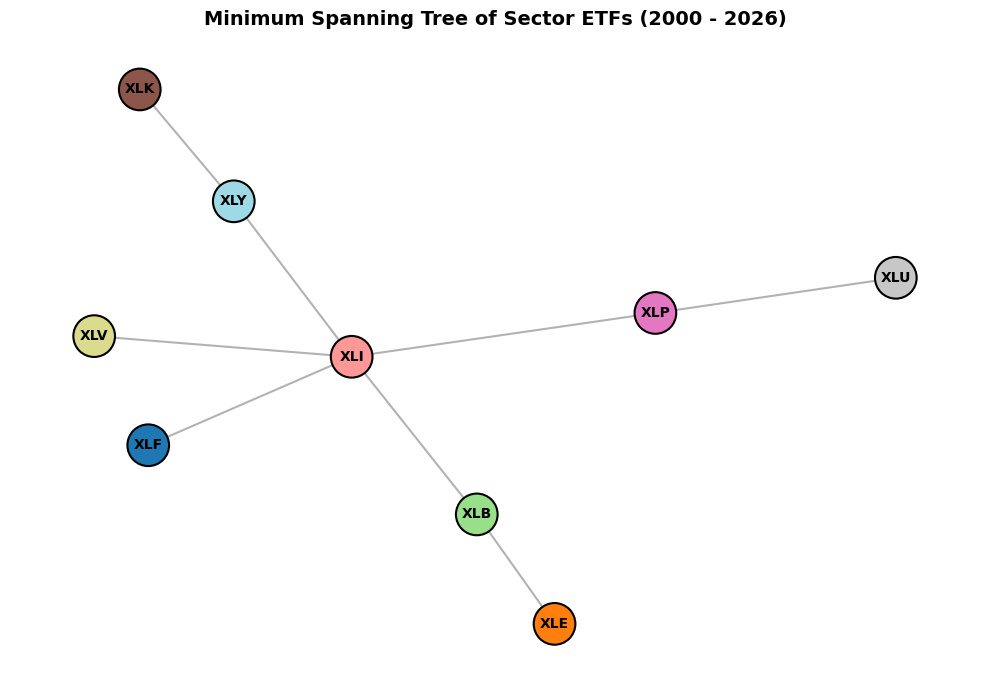

In [24]:
global_mst = mst_graph(distance_matrix.values, df_logreturns.columns[1:].tolist())

plt.figure(figsize=(8, 6.5))
pos = nx.spring_layout(global_mst, seed = 40, k=0.5)

nodes = list(global_mst.nodes())
n = len(nodes)
cmap = plt.cm.get_cmap("tab20", n)
node_colors = [cmap(i) for i in range(n)]

plt.figure(figsize=(10, 7))

nx.draw_networkx_edges(global_mst, pos, edge_color="gray", alpha=0.6, width=1.5)
nx.draw_networkx_nodes(global_mst, pos, node_color=node_colors, node_size=900, edgecolors="black", linewidths=1.5)
nx.draw_networkx_labels(global_mst, pos, font_size=10, font_weight="bold")

plt.title("Minimum Spanning Tree of Sector ETFs (2000 - 2026)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig("images/fig4_mst_sectors2000.png", dpi=200, bbox_inches="tight")
plt.show()

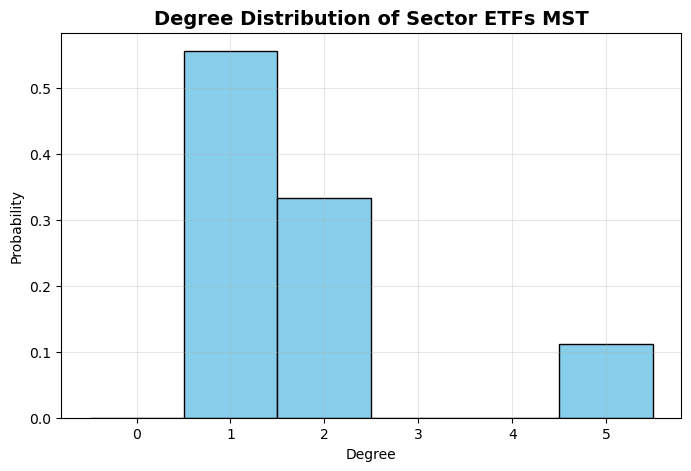

In [25]:
degree_distribution = [degree for node, degree in global_mst.degree()]

plt.figure(figsize=(8, 5))
plt.hist(degree_distribution, bins=np.arange(0, max(degree_distribution) + 2) - 0.5, density=True, color="skyblue", edgecolor="black")
plt.title("Degree Distribution of Sector ETFs MST", fontsize=14, fontweight="bold")
plt.xlabel("Degree")
plt.ylabel("Probability")
plt.grid(True, alpha=0.3)
plt.savefig("images/fig5_degree_dist_mst_sectors2000.png", dpi=200, bbox_inches="tight")
plt.show()

### Local Relationship (epoch_length = 40, epoch_shift = 20)

In [26]:
epoch_length = 40
epoch_shift = 20

stock_names = df_logreturns.columns[1:].tolist()

correlation_matrices = []
distance_matrices = []
mu_values = []
density_values = []
epoch_dates = []

for i in range(0, len(df_logreturns) - epoch_length, epoch_shift):
  epoch = df_logreturns.iloc[i:i+epoch_length]

  correlation_matrix = epoch.iloc[:, 1:].corr().values
  distance_matrix = np.sqrt(2 * (1 - correlation_matrix))
  mu = np.mean(correlation_matrix)
  density = np.sum(distance_matrix > 0) / (distance_matrix.shape[0] * (distance_matrix.shape[1] - 1))

  correlation_matrices.append(correlation_matrix)
  distance_matrices.append(distance_matrix)
  mu_values.append(mu)
  density_values.append(density)

  epoch_dates.append(epoch["Date"].iloc[-1])

print(len(correlation_matrices))

328


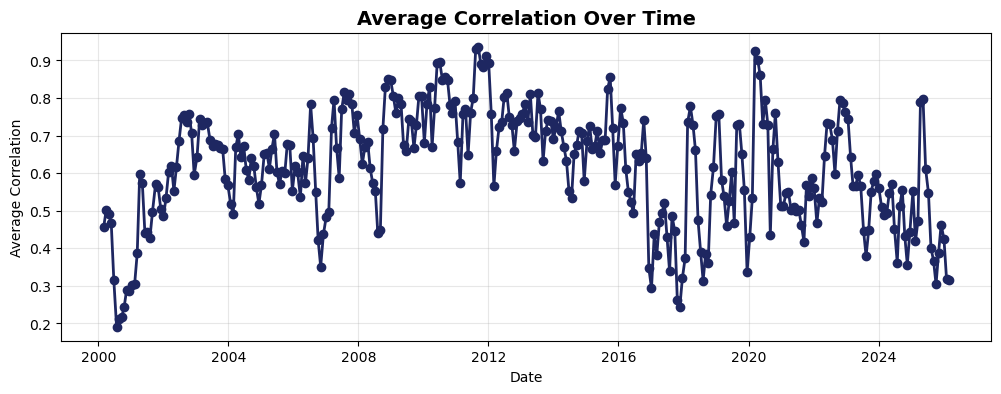

In [27]:
plt.figure(figsize=(12, 4))
plt.plot(epoch_dates, mu_values, color="#1E2761", label="Average Correlation", marker="o", linewidth=2)
plt.title("Average Correlation Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Average Correlation")
plt.grid(True, alpha=0.3)
plt.savefig("images/fig6_avg_corr_sectors2000.png", dpi=200, bbox_inches="tight")
plt.show()

In [28]:
mst_graphs = []
central_nodes = []
for D in distance_matrices:
    G = mst_graph(D, stock_names=stock_names)
    centrality = nx.eigenvector_centrality(G)
    central_node = max(centrality, key=centrality.get)
    central_nodes.append(central_node)
    mst_graphs.append(G)

threshold_graphs = []
for C in correlation_matrices:
    G = threshold_graph(C, stock_names=stock_names, corr_threshold=0.75)
    threshold_graphs.append(G)

mst_threshold_graphs = []
for C, D in zip(correlation_matrices, distance_matrices):
    G = mst_threshold_graph(C, D, stock_names=stock_names, corr_threshold=0.75)
    mst_threshold_graphs.append(G)

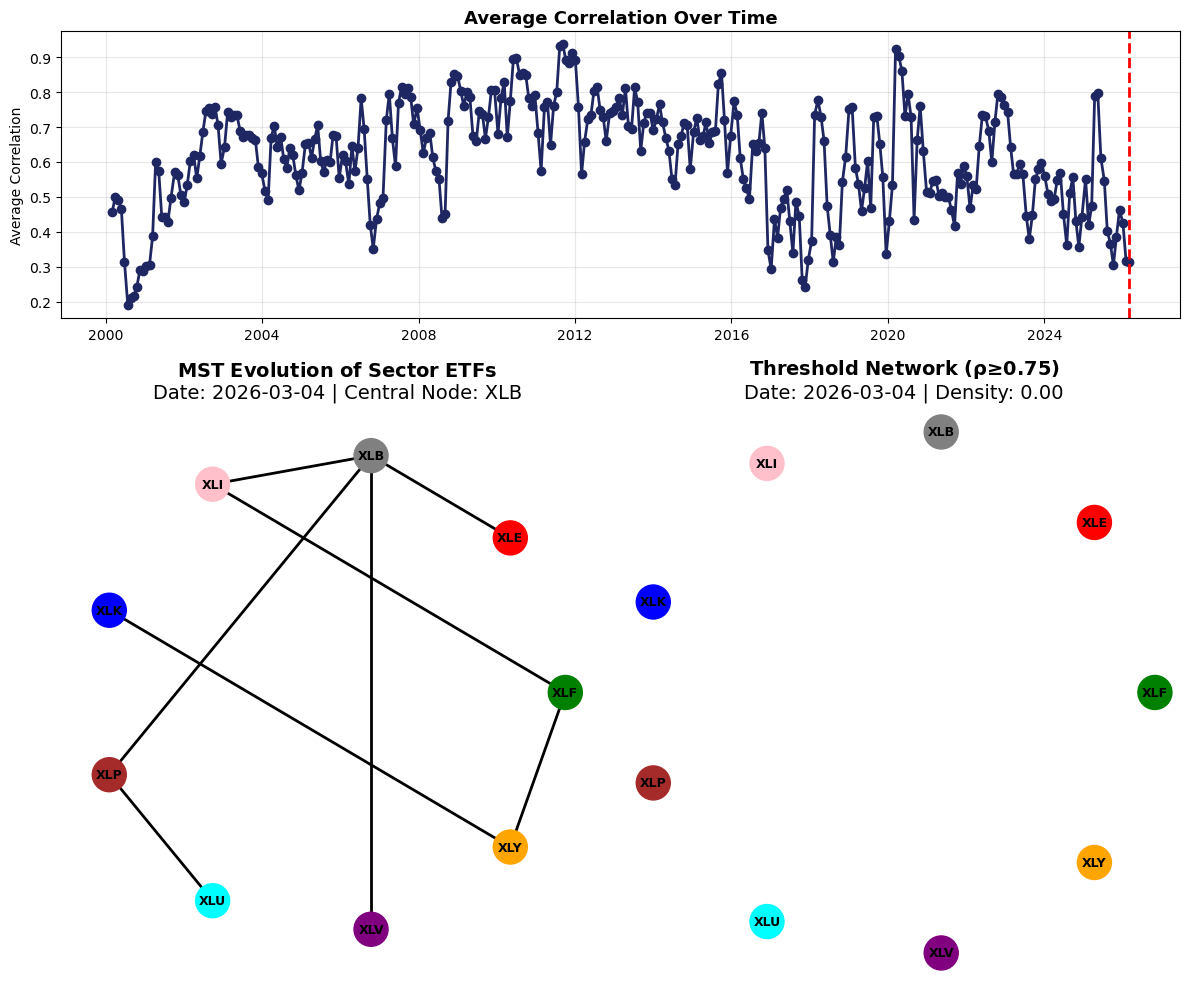

In [29]:
sector_colors = {
    "XLK": "blue",     # Tech
    "XLF": "green",    # Financials
    "XLE": "red",      # Energy
    "XLV": "purple",   # Healthcare
    "XLY": "orange",   # Consumer Discretionary
    "XLP": "brown",    # Consumer Staples
    "XLI": "pink",     # Industrials
    "XLB": "gray",     # Materials
    "XLU": "cyan",     # Utilities
}

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 2])

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

fig.subplots_adjust(hspace=0.35, wspace=0.2)

pos = nx.circular_layout(mst_graphs[0])

def update(frame):
    ax1.clear()

    ax1.plot(epoch_dates, mu_values, color="#1E2761", marker="o", linewidth=2)
    ax1.axvline(x=epoch_dates[frame], color="red", linewidth=2, linestyle="--")
    ax1.set_title("Average Correlation Over Time", fontsize=13, fontweight="bold")
    ax1.set_ylabel("Average Correlation")
    ax1.grid(True, alpha=0.3)

    ax2.clear()

    G_mst = mst_graphs[frame]
    node_colors = [sector_colors.get(node, "lightblue") for node in G_mst.nodes()]
    nx.draw_networkx_edges(G_mst, pos, ax=ax2, edge_color="black", width=2)
    nx.draw_networkx_nodes(G_mst, pos, ax=ax2, node_color=node_colors, node_size=600)
    nx.draw_networkx_labels(G_mst, pos, ax=ax2, font_size=9, font_weight="bold")

    ax2.set_title(r"$\bf{MST\ Evolution\ of\ Sector\ ETFs}$" + "\n" + f"Date: {epoch_dates[frame].date()} | Central Node: {central_nodes[frame]}", fontsize=14)
    ax2.axis("off")

    ax3.clear()

    G_thr = threshold_graphs[frame]
    nx.draw_networkx_edges(G_thr, pos, ax=ax3, edge_color="black", width=2)
    nx.draw_networkx_nodes(G_thr, pos, ax=ax3, node_color=node_colors, node_size=600)
    nx.draw_networkx_labels(G_thr, pos, ax=ax3, font_size=9, font_weight="bold")

    ax3.set_title(r"$\bf{Threshold\ Network\ (ρ ≥ 0.75)}$" + "\n" + f"Date: {epoch_dates[frame].date()} | Density: {nx.density(G_thr):.2f}", fontsize=14)
    ax3.axis("off")


ani = animation.FuncAnimation(fig, update, frames=len(mst_graphs), interval=280, repeat=True)
ani.save("MST_evolution_sectors2000.mp4", writer="ffmpeg", dpi=300)

plt.tight_layout()
plt.show()